# 04 · xFG Success Modeling v2 (IPW)

**Purpose:** Fit baseline and IPW-weighted models for field goal success with methodological corrections.

**Inputs:**
- `data/fg_attempts.csv` (from `01_data_prep.ipynb`)
- `data/fg_nonattempts.csv` (from `01_data_prep.ipynb`)

**Outputs:**
- `reports/xfg_success_v2/`

**Methodological Updates (v2):**
1.  **Continuous Weights:** The IPW model (M2) now uses continuous, un-rounded weights directly from the `weight_multinom_hajek` column.
2.  **Rationality Check:** A new visualization compares the predicted make probability of actual kicks vs. hypothetical non-attempts to check if coaches avoid low-probability kicks.
3.  **Tail Calibration:** A new evaluation block assesses model performance specifically on high-difficulty kicks (`kick_distance >= 50`), where calibration is most challenging.

## 1. Setup: Parameters & Libraries

In [1]:
# Parameters
PROJECT_ROOT <- normalizePath('G:/My files/Python/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model', winslash = '\\', mustWork = FALSE)
data_dir <- file.path(PROJECT_ROOT, 'data')
reports_dir <- file.path(PROJECT_ROOT, 'reports', 'xfg_success_v2')
models_dir <- file.path(PROJECT_ROOT, 'models')

if (!dir.exists(reports_dir)) {
  dir.create(reports_dir, recursive = TRUE, showWarnings = FALSE)
}

set.seed(20240517)

In [2]:
# Imports — install if missing
dependencies <- c(
  'tidyverse', 'glmmTMB', 'splines', 'yardstick', 'pROC'
)

installed <- rownames(installed.packages())

for (pkg in dependencies) {
  if (!pkg %in% installed) {
    install.packages(pkg)
  }
  suppressPackageStartupMessages(library(pkg, character.only = TRUE))
}

## 2. Data Loading & Preparation

In [3]:
# Load datasets created in 01_data_prep and 03_attempt_pi
attempts_path <- file.path(data_dir, 'fg_attempts.csv')
non_attempts_path <- file.path(data_dir, 'fg_nonattempts.csv')
weights_path <- file.path(PROJECT_ROOT, 'reports', 'attempt_pi', 'attempt_pi_oof_predictions_final.csv')

stopifnot(file.exists(attempts_path), file.exists(non_attempts_path), file.exists(weights_path))

attempts_df <- readr::read_csv(attempts_path, show_col_types = FALSE)
non_attempts_df <- readr::read_csv(non_attempts_path, show_col_types = FALSE)
weights_df <- readr::read_csv(weights_path, show_col_types = FALSE) %>%
  dplyr::select(game_id, play_id, weight_multinom_hajek)

# Join weights to the attempts data
attempts_df <- attempts_df %>%
  dplyr::left_join(weights_df, by = c("game_id", "play_id")) %>%
  dplyr::filter(!is.na(weight_multinom_hajek)) # Ensure all attempts have a weight

# Simple train/test split on attempts data by season
train_df <- attempts_df %>% dplyr::filter(season < 2023)
test_df <- attempts_df %>% dplyr::filter(season >= 2023)

cat(sprintf("Train set: %d attempts\nTest set: %d attempts\nNon-attempts: %d plays\n",
            nrow(train_df), nrow(test_df), nrow(non_attempts_df)))

Train set: 8351 attempts
Test set: 2273 attempts
Non-attempts: 38780 plays


## 3. Model Fitting

**M1 (Baseline):** Unweighted model.

**M2 (IPW):** Weighted model using continuous `weight_multinom_hajek` weights to correct for selection bias. This is the **critical fix**.

In [4]:
# Define the model formula and glmmTMB control for better convergence
m_formula <- kick_made ~ ns(kick_distance, df = 4) + wind_z * temp_z + indoors +
                         (1 | stadium_id) + (1 | season:kicker_player_id)

ctrl <- glmmTMBControl(optimizer = optim, optArgs = list(method = "BFGS"))

cat("--- Fitting Models ---\n")

# M1: Baseline Model (Unweighted)
cat("Fitting M1 (Baseline, unweighted)...")
fit_m1 <- glmmTMB(
  formula = m_formula,
  data = train_df,
  family = binomial(link = "cloglog"),
  control = ctrl
)
cat(" Done.\n")

# M2: IPW Model with Continuous Weights (CRITICAL FIX)
# The continuous 'weight_multinom_hajek' column is passed directly.
cat("Fitting M2 (IPW, continuous weights)...")
fit_m2 <- glmmTMB(
  formula = m_formula,
  data = train_df,
  family = binomial(link = "cloglog"),
  weights = weight_multinom_hajek, # <-- CRITICAL FIX
  control = ctrl
)
cat(" Done.\n")

cat("Model fitting complete.\n")

--- Fitting Models ---
Fitting M1 (Baseline, unweighted)... Done.
Fitting M2 (IPW, continuous weights)...

Warning message in eval(family$initialize):
"non-integer #successes in a binomial glm!"


 Done.
Model fitting complete.


## 4. Rationality Check (Path A)

This visualization checks if the field goals that were *not* attempted (i.e., punts or go-for-it plays on 4th down) had a lower predicted probability of success than the field goals that *were* attempted. If coaches are rational, we expect to see the distribution for non-attempts shifted to the left (lower xFG).

--- Generating Rationality Check Visualization ---


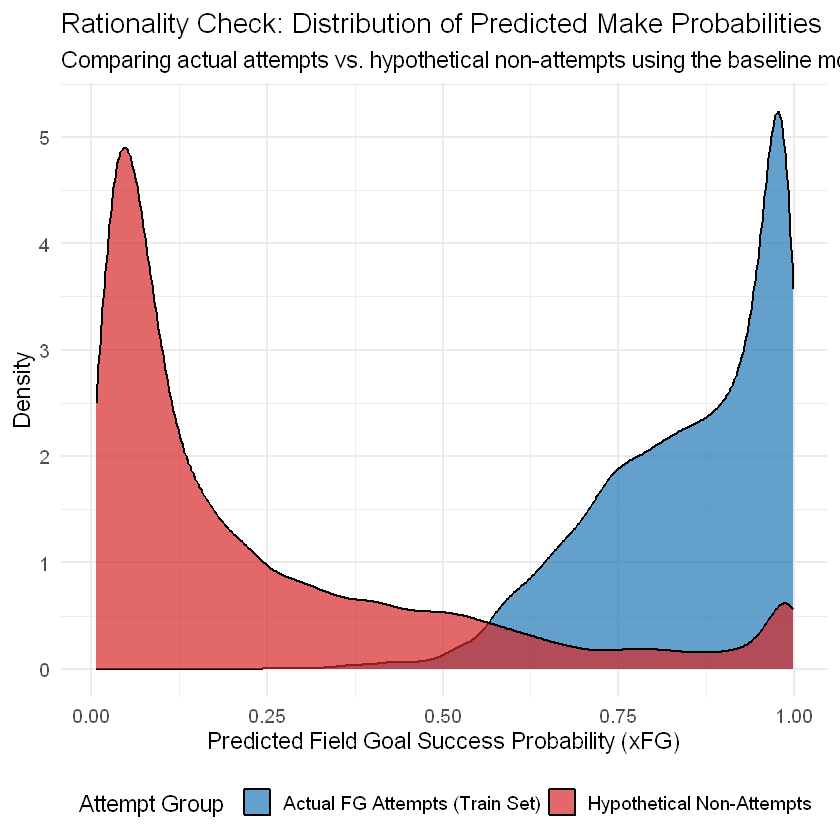

In [5]:
cat("--- Generating Rationality Check Visualization ---\n")

# Predict make probability on both actual attempts and non-attempts using M1
# Use allow.new.levels=TRUE to handle any new stadiums/kickers in non_attempts_df
p_actual_attempts <- predict(fit_m1, newdata = train_df, type = "response", allow.new.levels = TRUE)
p_non_attempts <- predict(fit_m1, newdata = non_attempts_df, type = "response", allow.new.levels = TRUE)

# Combine predictions into a single dataframe for plotting
rationality_df <- bind_rows(
  tibble(pred_prob = p_actual_attempts, group = "Actual FG Attempts (Train Set)"),
  tibble(pred_prob = p_non_attempts, group = "Hypothetical Non-Attempts")
)

# Create the density plot
rationality_plot <- ggplot(rationality_df, aes(x = pred_prob, fill = group)) +
  geom_density(alpha = 0.7) +
  scale_fill_manual(values = c("Actual FG Attempts (Train Set)" = "#1f77b4", "Hypothetical Non-Attempts" = "#d62728")) +
  labs(
    title = "Rationality Check: Distribution of Predicted Make Probabilities",
    subtitle = "Comparing actual attempts vs. hypothetical non-attempts using the baseline model (M1)",
    x = "Predicted Field Goal Success Probability (xFG)",
    y = "Density",
    fill = "Attempt Group"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "bottom")

# Print the plot to the notebook output
print(rationality_plot)

# Save the plot
ggsave(file.path(reports_dir, "rationality_check_density.png"), rationality_plot, width = 10, height = 6, dpi = 300)

## 5. Model Evaluation

### 5a. Overall Performance

Standard metrics (AUC, Brier Score) calculated on the full test set.

In [9]:
cat("--- Evaluating Models on Full Test Set ---\n")

# Generate predictions on the full test set
test_preds <- test_df %>% 
  mutate(
    p_m1 = predict(fit_m1, newdata = ., type = "response", allow.new.levels = TRUE),
    p_m2 = predict(fit_m2, newdata = ., type = "response", allow.new.levels = TRUE)
  )

# Calculate overall performance metrics
overall_metrics <- tibble(
  model = c("M1_baseline", "M2_ipw"),
  auc = c(
    roc(test_preds$kick_made, test_preds$p_m1, quiet = TRUE)$auc,
    roc(test_preds$kick_made, test_preds$p_m2, quiet = TRUE)$auc
  ),
  brier = c(
    yardstick::brier_class_vec(truth = as.factor(test_preds$kick_made), estimate = test_preds$p_m1),
    yardstick::brier_class_vec(truth = as.factor(test_preds$kick_made), estimate = test_preds$p_m2)
  )
)

print("Overall Metrics (Full Test Set):")
print(overall_metrics)

--- Evaluating Models on Full Test Set ---


[1] "Overall Metrics (Full Test Set):"
# A tibble: 2 × 3
  model         auc brier
  <chr>       <dbl> <dbl>
1 M1_baseline 0.765 0.645
2 M2_ipw      0.742 0.652


### 5b. Tail Calibration on High-Difficulty Kicks (Path B)

This block evaluates model performance specifically on kicks of 50+ yards. Standard metrics are often dominated by the high volume of short, easy kicks. This analysis provides a more challenging and insightful test of model calibration.

In [10]:
cat("\n--- Evaluating Tail Performance (Kick Distance >= 50) ---\n")

# Filter test set for high-difficulty kicks
test_set_hard <- test_preds %>%
  filter(kick_distance >= 50)

if (nrow(test_set_hard) > 0) {
  # Calculate Brier Score on the difficult subset
  tail_brier <- tibble(
    model = c("M1_baseline", "M2_ipw"),
    brier_score_50plus = c(
      yardstick::brier_class_vec(truth = as.factor(test_set_hard$kick_made), estimate = test_set_hard$p_m1),
      yardstick::brier_class_vec(truth = as.factor(test_set_hard$kick_made), estimate = test_set_hard$p_m2)
    )
  )

  # Calculate Calibration Error (Mean Predicted vs. Mean Actual) on the subset
  tail_calib <- test_set_hard %>% 
    summarise(
      cal_error_m1 = mean(p_m1) - mean(kick_made),
      cal_error_m2 = mean(p_m2) - mean(kick_made),
      n_obs = n()
    ) %>%
    pivot_longer(
      cols = starts_with("cal_error"),
      names_to = "model",
      names_prefix = "cal_error_",
      values_to = "calibration_error_50plus"
    ) %>% 
    mutate(model = recode(model, "m1" = "M1_baseline", "m2" = "M2_ipw"))

  # Combine and print tail metrics
  tail_metrics <- left_join(tail_brier, tail_calib, by = "model")

  print("Tail Metrics (Kick Distance >= 50):")
  print(tail_metrics)
  
  # Save all metrics to a single file
  all_metrics <- left_join(overall_metrics, tail_metrics, by = "model")
  readr::write_csv(all_metrics, file.path(reports_dir, "model_metrics_summary.csv"))

} else {
  cat("No kicks with distance >= 50 found in the test set. Skipping tail evaluation.\n")
  readr::write_csv(overall_metrics, file.path(reports_dir, "model_metrics_summary.csv"))
}

cat("\n--- Analysis Complete ---\n")


--- Evaluating Tail Performance (Kick Distance >= 50) ---
[1] "Tail Metrics (Kick Distance >= 50):"
# A tibble: 2 × 4
  model       brier_score_50plus n_obs calibration_error_50plus
  <chr>                    <dbl> <int>                    <dbl>
1 M1_baseline              0.330   527                  -0.0736
2 M2_ipw                   0.354   527                  -0.0655

--- Analysis Complete ---
